In [1]:
import pandas as pd
df = pd.read_csv('fooddelivery_updated.csv')
df.head()

,content,score,thumbsUpCount,Apps
0,deleted dont like being called out for not tip...,1,0,DoorDash
1,while abbreviation msg fitters outed gudsmoked...,5,0,DoorDash
2,They come through especially when your running...,5,0,DoorDash
3,I love DoorDash,5,0,DoorDash
4,THEY STEAL MONEY! I used to order often and of...,1,0,DoorDash


In [2]:
def sentiment(n):
    if (n>=4):
        return 1
    elif (n==3):
        return 0;
    else:
            #for x in range(2,1):
                return -1
df['sentiment'] = df['score'].apply(sentiment)
df.head(3)

,content,score,thumbsUpCount,Apps,sentiment
0,deleted dont like being called out for not tip...,1,0,DoorDash,-1
1,while abbreviation msg fitters outed gudsmoked...,5,0,DoorDash,1
2,They come through especially when your running...,5,0,DoorDash,1


In [3]:
print(df["sentiment"].value_counts())

 1    1148260
-1     467643
 0      79035
Name: sentiment, dtype: int64


In [5]:
pd.crosstab(df.Apps, df.sentiment)

sentiment,-1,0,1
Apps,,,
DoorDash,128902,30137,478182
Grubhub,53212,12065,126291
Uber_Eats,285529,36833,543787


In [6]:
pd.crosstab(df.Apps, df.score)

score,0,1,2,3,4,5
Apps,,,,,,
DoorDash,0,108661,20241,30137,84639,393543
Grubhub,1,43572,9639,12065,24888,101403
Uber_Eats,0,256678,28851,36833,81495,462292


In [8]:
from afinn import Afinn
afinn = Afinn(language='en')

In [12]:
df['content']=df['content'].apply(str)

In [13]:
seed = 808 # seed for sample so results are stable
df.sample(10, random_state = seed)

,content,score,thumbsUpCount,Apps,sentiment
550696,great app!,5,0,DoorDash,1
868200,Ya casi no mandan promociones ni teniendo la s...,5,0,Uber_Eats,1
1464137,Works great!,5,0,Uber_Eats,1
1669164,Doesnt allow me to go past setting my delivery...,1,6,Uber_Eats,-1
264499,"Basically Highway Robbery, double dipping with...",1,0,DoorDash,-1
1093056,I have ordered 5 time from this app and only 1...,1,2,Uber_Eats,-1
1364824,Amazing App !!,5,0,Uber_Eats,1
298371,I use door dash every week. Good personel. Mak...,5,0,DoorDash,1
1655443,Downloaded app tried to register and it keeps ...,2,0,Uber_Eats,-1
639044,fees are stupid,1,0,Grubhub,-1


In [14]:
df['afinn_score'] = df['content'].apply(afinn.score)

In [15]:
columns_to_display = ['Apps','content', 'score', 'thumbsUpCount', 'afinn_score']
df.sort_values(by='afinn_score')[columns_to_display].head(10)

,Apps,content,score,thumbsUpCount,afinn_score
1360609,Uber_Eats,"Uber eat become worst company now, i chargers ...",1,1,-108.0
405745,DoorDash,Really awful app. Abusive to employees and cus...,1,0,-48.0
217246,DoorDash,WHAT A WASTE OF TIME AND MONEY! WHAT A RIP OFF...,5,0,-44.0
1528588,Uber_Eats,BAD EXPERIENCE! Actually several bad experienc...,1,12,-41.0
1620483,Uber_Eats,Very bad and worst app By mistake i pay the bi...,1,0,-37.0
262375,DoorDash,I'm a dasher and they use the app to mess with...,1,0,-36.0
1539915,Uber_Eats,Update: another issue. This is the very last t...,1,1,-35.0
709312,Grubhub,"Bad, bad, bad, bad, bad. Please do not use thi...",1,0,-33.0
880638,Uber_Eats,I would not recommend this app or service. Ter...,1,1,-30.0
1552283,Uber_Eats,Absolutely appalling. Delivery driver was rude...,1,0,-30.0


In [16]:
columns_to_display = ['Apps','content', 'score', 'thumbsUpCount', 'afinn_score']
df.sort_values(by='afinn_score')[columns_to_display].tail(10)

,Apps,content,score,thumbsUpCount,afinn_score
390961,DoorDash,I love this app!! Real convenient for a single...,5,91,34.0
369407,DoorDash,FRICKIN LOVE DOOR DASH!!!!! Cant say enough go...,5,0,34.0
1135651,Uber_Eats,"•good (go͝od) adjective bet·ter (bĕt′ər), best...",5,0,35.0
952715,Uber_Eats,The man did good bring me donuts yummy yummy t...,5,0,35.0
117424,DoorDash,Awesome Awesome Awesome Awesome Awesome Awesom...,5,0,36.0
1614040,Uber_Eats,This is probably the best aap I could everrrrr...,5,1,36.0
368177,DoorDash,best food delivery app ever totally addicted f...,5,10,38.0
899963,Uber_Eats,I like the app and I am great because it is a ...,5,0,45.0
875791,Uber_Eats,Very good service pure Goodness of the Lord Go...,5,0,48.0
782817,Grubhub,Used this & it was pretty easy to order & pay ...,4,0,80.0


In [17]:
Negative_sample = df.iloc[1360609]['content']
print(Negative_sample)

Uber eat become worst company now, i chargers twice too many time and when i complaint about that, they have no resolution for that.  Most important they don't have customer care number.  FRAUD FRAUD FRAUD FRAUD FRAUD FRAUD FRAUD FRAUD FRAUD FRAUD FRAUD FRAUD FRAUD FRAUD FRAUD FRAUD FRAUD FRAUD FRAUD FRAUD FRAUD FRAUD FRAUD FRAUD FRAUD FRAUD FRAUD


In [18]:
Positive_sample = df.iloc[782817]['content']
print(Positive_sample)

Used this & it was pretty easy to order & pay but I had to download PayPal to pay & it took awhile to setup both apps but once I did it was very smooth & they work perfectly together & I love that it saves your previous orders so next time you know exactly what it was you liked if you never had it before which I hadn't lol but loved the food & the delivery girl was super sweet even though she got lost & was a little late the food was still hot & her great personality made up for it being late! Will definitely use again just wish there was ways to get discounts on delivery like coupons or doing a review to get a few dollars off like how on the receipt from fast food if you do a survey u get a free food item. Just to help cuz it's great to get real food from real restaurants but it's ALOT more expensive then fast food which many deliver now too so it's easier to settle for cheaper faster food even if it's not as good simply cuz many people don't have the money to splurge for the better s

In [19]:
df.groupby('sentiment')['afinn_score'].describe()

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
-1,467643.0,-1.603732,3.502804,-108.0,-3.0,-1.0,0.0,25.0
0,79035.0,0.697767,2.933286,-25.0,-1.0,0.0,3.0,27.0
1,1148260.0,2.666376,2.467823,-44.0,1.0,3.0,3.0,80.0


In [20]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [21]:
df = df[pd.notnull(df['content'])]

In [23]:
len(df)

1694938

In [24]:
analyzer = SentimentIntensityAnalyzer()
analyzer.polarity_scores('Horrible bad day.')

{'neg': 0.875, 'neu': 0.125, 'pos': 0.0, 'compound': -0.7906}

In [25]:
sentiment = df['content'].apply(analyzer.polarity_scores)

In [26]:
sentiment_df = pd.DataFrame(sentiment.tolist())

sentiment_df.head()

,neg,neu,pos,compound
0,0.102,0.814,0.084,0.1002
1,0.000,0.561,0.439,0.9100
2,0.000,0.841,0.159,0.2235
3,0.000,0.323,0.677,0.6369
4,0.135,0.851,0.014,-0.9148


In [27]:
def vaderize(df, textfield):
    '''Compute the Vader polarity scores for a textfield.
    Returns scores and original dataframe.'''

    analyzer = SentimentIntensityAnalyzer()

    print('Estimating polarity scores for %d cases.' % len(df))
    sentiment = df[textfield].apply(analyzer.polarity_scores)

    # convert to dataframe
    sdf = pd.DataFrame(sentiment.tolist()).add_prefix('vader_')

    # merge dataframes
    df_combined = pd.concat([df, sdf], axis=1)
    return df_combined

In [28]:
df_vaderized = vaderize(df, 'content')

Estimating polarity scores for 1694938 cases.


In [29]:
df_vaderized.head()

,content,score,thumbsUpCount,Apps,sentiment,afinn_score,vader_neg,vader_neu,vader_pos,vader_compound
0,deleted dont like being called out for not tip...,1,0,DoorDash,-1,-1.0,0.102,0.814,0.084,0.1002
1,while abbreviation msg fitters outed gudsmoked...,5,0,DoorDash,1,7.0,0.000,0.561,0.439,0.9100
2,They come through especially when your running...,5,0,DoorDash,1,-1.0,0.000,0.841,0.159,0.2235
3,I love DoorDash,5,0,DoorDash,1,3.0,0.000,0.323,0.677,0.6369
4,THEY STEAL MONEY! I used to order often and of...,1,0,DoorDash,-1,-10.0,0.135,0.851,0.014,-0.9148


In [30]:
sentiment_variables = ['vader_compound', 'vader_neg', 'vader_neu', 'vader_pos', 'afinn_score' ]
df_vaderized.groupby('sentiment')[sentiment_variables].mean()

,vader_compound,vader_neg,vader_neu,vader_pos,afinn_score
sentiment,,,,,
-1,-0.245619,0.155439,0.788441,0.056119,-1.603732
0,0.095444,0.079591,0.758536,0.161872,0.697767
1,0.475456,0.019015,0.500379,0.480607,2.666376


In [31]:
sentiment_variables2 = ['vader_compound', 'vader_neg', 'vader_neu', 'vader_pos', 'afinn_score' ]
df_vaderized.groupby('Apps')[sentiment_variables2].mean()

,vader_compound,vader_neg,vader_neu,vader_pos,afinn_score
Apps,,,,,
DoorDash,0.330291,0.044070,0.587532,0.368398,1.720839
Grubhub,0.266917,0.057030,0.644499,0.298471,1.450874
Uber_Eats,0.204384,0.071359,0.583469,0.345172,1.145728


<AxesSubplot:xlabel='vader_compound', ylabel='Apps'>

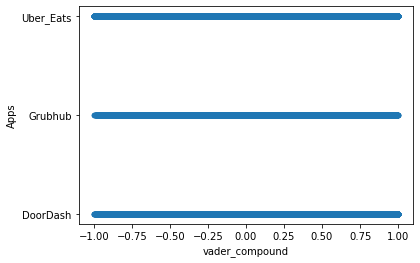

In [32]:
df_vaderized.plot.scatter(x='vader_compound', y = 'Apps')

In [39]:
def word_count(text_string):
    '''Calculate the number of words in a string'''
    return len(text_string.split())
word_count('This sentence has seven words in it.')

7

In [40]:
df_vaderized['word_count'] = df_vaderized['content'].apply(word_count)

In [41]:
df_vaderized.groupby('sentiment')['word_count'].describe()

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
-1,467643.0,32.703479,28.366569,1.0,11.0,24.0,48.0,747.0
0,79035.0,23.043930,23.630614,1.0,6.0,15.0,32.0,423.0
1,1148260.0,8.809194,12.244466,1.0,2.0,4.0,11.0,774.0


In [42]:
sentiment_variables = ['vader_compound', 'vader_neg', 'vader_neu', 'vader_pos', 'afinn_score', 'word_count' ]
df_vaderized.groupby('sentiment')[sentiment_variables].mean()

,vader_compound,vader_neg,vader_neu,vader_pos,afinn_score,word_count
sentiment,,,,,,
-1,-0.245619,0.155439,0.788441,0.056119,-1.603732,32.703479
0,0.095444,0.079591,0.758536,0.161872,0.697767,23.043930
1,0.475456,0.019015,0.500379,0.480607,2.666376,8.809194


In [44]:
sentiment_variables2 = ['sentiment','vader_compound', 'vader_neg', 'vader_neu', 'vader_pos', 'afinn_score', 'word_count' ]
df_vaderized.groupby('Apps')[sentiment_variables2].mean()

,sentiment,vader_compound,vader_neg,vader_neu,vader_pos,afinn_score,word_count
Apps,,,,,,,
DoorDash,0.548130,0.330291,0.044070,0.587532,0.368398,1.720839,15.433201
Grubhub,0.381478,0.266917,0.057030,0.644499,0.298471,1.450874,18.116664
Uber_Eats,0.298168,0.204384,0.071359,0.583469,0.345172,1.145728,16.077074


In [45]:
# Save the updated dataset to a new CSV file
df_vaderized.to_csv('fooddelivery_updated_sentiment.csv', index=False)

In [46]:
df_vaderized.head()

,content,score,thumbsUpCount,Apps,sentiment,afinn_score,vader_neg,vader_neu,vader_pos,vader_compound,word_count
0,deleted dont like being called out for not tip...,1,0,DoorDash,-1,-1.0,0.102,0.814,0.084,0.1002,31
1,while abbreviation msg fitters outed gudsmoked...,5,0,DoorDash,1,7.0,0.000,0.561,0.439,0.9100,20
2,They come through especially when your running...,5,0,DoorDash,1,-1.0,0.000,0.841,0.159,0.2235,11
3,I love DoorDash,5,0,DoorDash,1,3.0,0.000,0.323,0.677,0.6369,3
4,THEY STEAL MONEY! I used to order often and of...,1,0,DoorDash,-1,-10.0,0.135,0.851,0.014,-0.9148,96
